In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
forex_data = pd.read_csv("Cleaned_data/forex_price_data_cleaned.csv")

In [3]:
forex_data["DateTime"] = pd.to_datetime(forex_data["DateTime"])

In [4]:
forex_data.head()

,DateTime,PairID,PairName,Open,High,Low,Close,Volume,Spread
0,2023-01-01 00:00:00,1,EUR/USD,1.08103,1.08103,1.08019,1.08054,2651,0.9
1,2023-01-01 01:00:00,1,EUR/USD,1.08010,1.08043,1.07974,1.08028,2292,1.0
2,2023-01-01 02:00:00,1,EUR/USD,1.08036,1.08158,1.07961,1.08054,1796,1.2
3,2023-01-01 03:00:00,1,EUR/USD,1.08068,1.08126,1.07973,1.08088,4019,1.4
4,2023-01-01 04:00:00,1,EUR/USD,1.08042,1.08042,1.07967,1.08030,2207,1.6


In [5]:
forex_data["SMA_10"] = forex_data["Close"].rolling(window=10).mean()

In [6]:
forex_data["SMA_20"] = forex_data["Close"].rolling(window=20).mean()

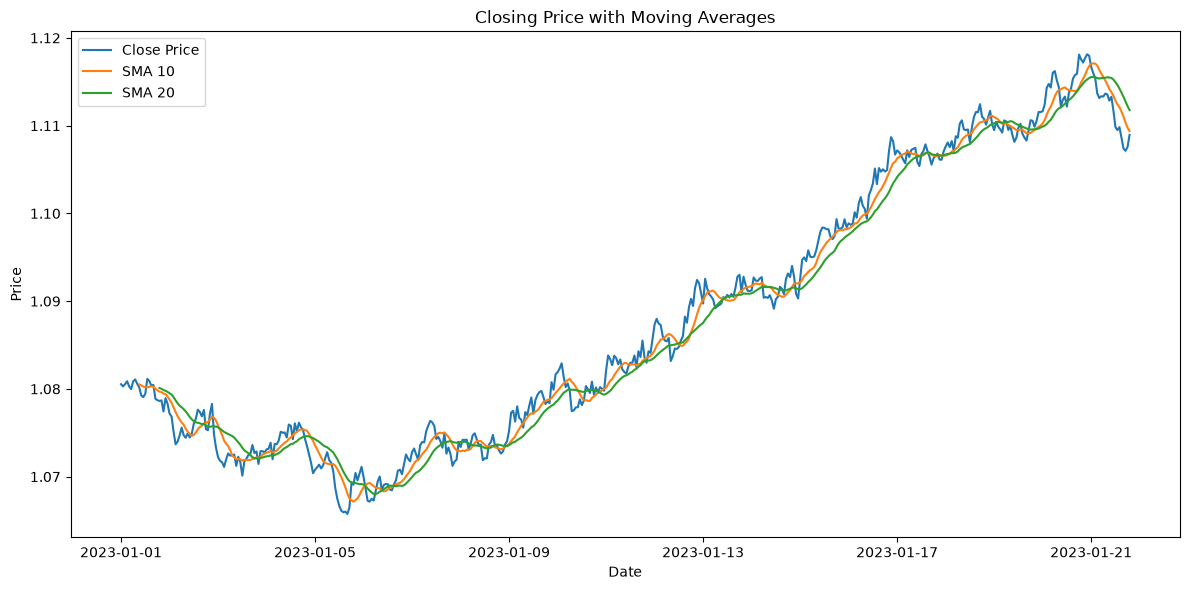

In [7]:
plt.figure(figsize=(12,6))

plt.plot(forex_data["DateTime"], forex_data["Close"], label="Close Price")

plt.plot(forex_data["DateTime"], forex_data["SMA_10"], label="SMA 10")

plt.plot(forex_data["DateTime"], forex_data["SMA_20"], label="SMA 20")

plt.title("Closing Price with Moving Averages")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.tight_layout()

plt.show()

In [8]:
forex_data["EMA_10"] = forex_data["Close"].ewm(span=10, adjust=False).mean()

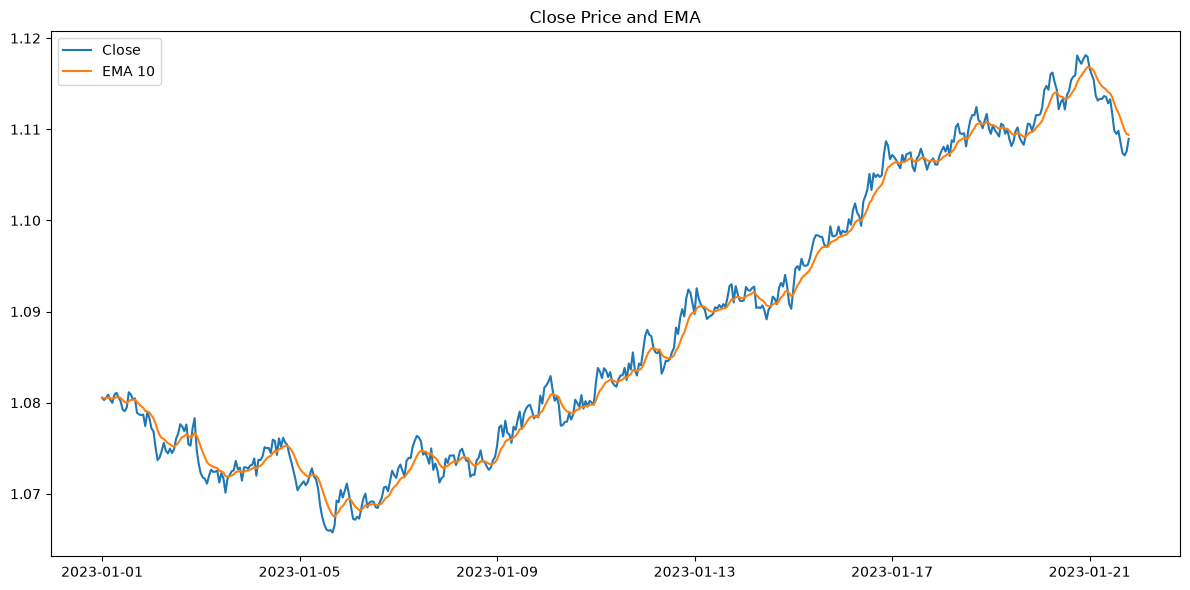

In [9]:
plt.figure(figsize=(12,6))

plt.plot(forex_data["DateTime"], forex_data["Close"], label="Close")

plt.plot(forex_data["DateTime"], forex_data["EMA_10"], label="EMA 10")

plt.title("Close Price and EMA")

plt.legend()

plt.tight_layout()

plt.show()

In [10]:
delta = forex_data["Close"].diff()

gain = delta.where(delta > 0, 0)

loss = -delta.where(delta < 0, 0)

average_gain = gain.rolling(14).mean()

average_loss = loss.rolling(14).mean()

rs = average_gain / average_loss

forex_data["RSI"] = 100 - (100 / (1 + rs))

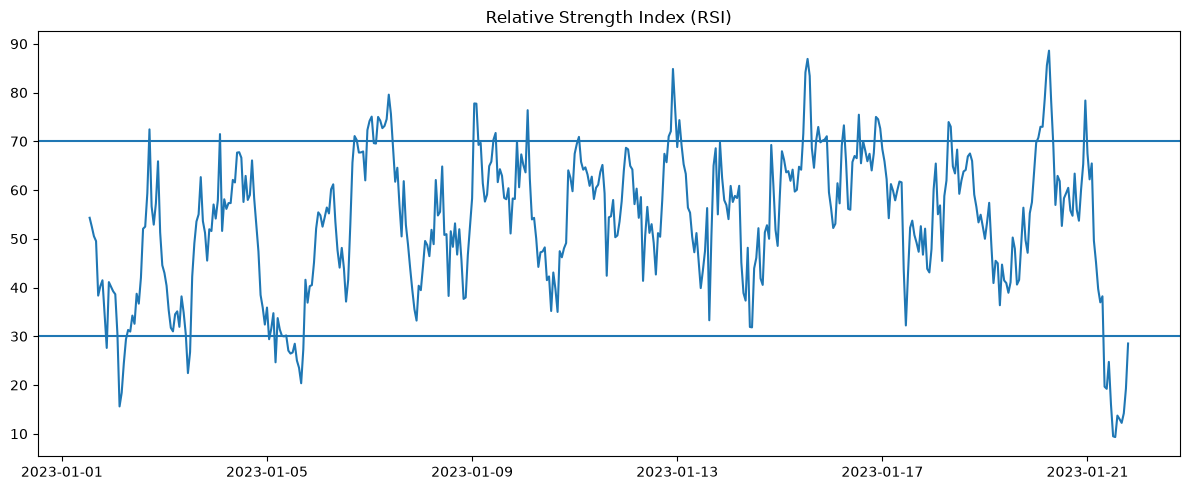

In [11]:
plt.figure(figsize=(12,5))

plt.plot(forex_data["DateTime"], forex_data["RSI"])

plt.axhline(70)

plt.axhline(30)

plt.title("Relative Strength Index (RSI)")

plt.tight_layout()

plt.show()

In [12]:
ema12 = forex_data["Close"].ewm(span=12, adjust=False).mean()

ema26 = forex_data["Close"].ewm(span=26, adjust=False).mean()

forex_data["MACD"] = ema12 - ema26

forex_data["Signal_Line"] = forex_data["MACD"].ewm(span=9, adjust=False).mean()

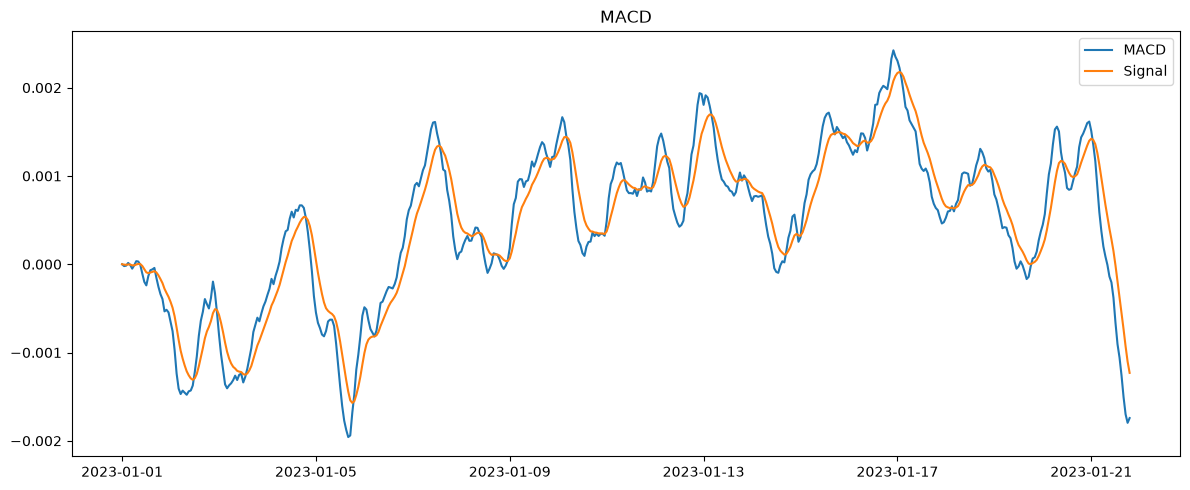

In [13]:
plt.figure(figsize=(12,5))

plt.plot(forex_data["DateTime"], forex_data["MACD"], label="MACD")

plt.plot(forex_data["DateTime"], forex_data["Signal_Line"], label="Signal")

plt.legend()

plt.title("MACD")

plt.tight_layout()

plt.show()

In [14]:
forex_data["Middle_Band"] = forex_data["Close"].rolling(20).mean()

std = forex_data["Close"].rolling(20).std()

forex_data["Upper_Band"] = forex_data["Middle_Band"] + (2 * std)

forex_data["Lower_Band"] = forex_data["Middle_Band"] - (2 * std)

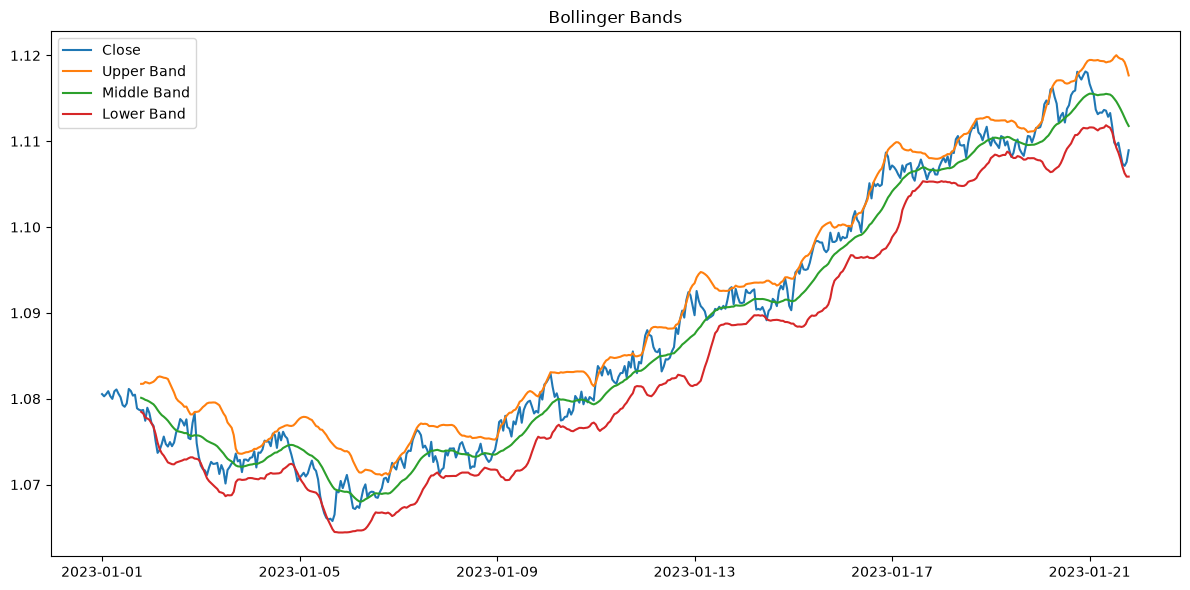

In [15]:
plt.figure(figsize=(12,6))

plt.plot(forex_data["DateTime"], forex_data["Close"], label="Close")

plt.plot(forex_data["DateTime"], forex_data["Upper_Band"], label="Upper Band")

plt.plot(forex_data["DateTime"], forex_data["Middle_Band"], label="Middle Band")

plt.plot(forex_data["DateTime"], forex_data["Lower_Band"], label="Lower Band")

plt.legend()

plt.title("Bollinger Bands")

plt.tight_layout()

plt.show()

In [16]:
forex_data.head(25)

,DateTime,PairID,PairName,Open,High,Low,Close,Volume,Spread,SMA_10,SMA_20,EMA_10,RSI,MACD,Signal_Line,Middle_Band,Upper_Band,Lower_Band
0,2023-01-01 00:00:00,1,EUR/USD,1.08103,1.08103,1.08019,1.08054,2651,0.9,NaN,NaN,1.080540,NaN,0.000000,0.000000,NaN,NaN,NaN
1,2023-01-01 01:00:00,1,EUR/USD,1.08010,1.08043,1.07974,1.08028,2292,1.0,NaN,NaN,1.080493,NaN,-0.000021,-0.000004,NaN,NaN,NaN
2,2023-01-01 02:00:00,1,EUR/USD,1.08036,1.08158,1.07961,1.08054,1796,1.2,NaN,NaN,1.080501,NaN,-0.000016,-0.000007,NaN,NaN,NaN
3,2023-01-01 03:00:00,1,EUR/USD,1.08068,1.08126,1.07973,1.08088,4019,1.4,NaN,NaN,1.080570,NaN,0.000015,-0.000002,NaN,NaN,NaN
4,2023-01-01 04:00:00,1,EUR/USD,1.08042,1.08042,1.07967,1.08030,2207,1.6,NaN,NaN,1.080521,NaN,-0.000007,-0.000003,NaN,NaN,NaN
5,2023-01-01 05:00:00,1,EUR/USD,1.07981,1.08053,1.07981,1.07998,2972,1.9,NaN,NaN,1.080423,NaN,-0.000050,-0.000013,NaN,NaN,NaN
6,2023-01-01 06:00:00,1,EUR/USD,1.08023,1.08153,1.08023,1.08087,1534,2.0,NaN,NaN,1.080504,NaN,-0.000012,-0.000012,NaN,NaN,NaN
7,2023-01-01 07:00:00,1,EUR/USD,1.08075,1.08120,1.08061,1.08108,1350,1.1,NaN,NaN,1.080609,NaN,0.000035,-0.000003,NaN,NaN,NaN
8,2023-01-01 08:00:00,1,EUR/USD,1.08001,1.08116,1.08001,1.08058,3505,0.9,NaN,NaN,1.080604,NaN,0.000031,0.000004,NaN,NaN,NaN
9,2023-01-01 09:00:00,1,EUR/USD,1.08046,1.08048,1.07969,1.08017,4348,0.9,1.080522,NaN,1.080525,NaN,-0.000005,0.000002,NaN,NaN,NaN


In [17]:
forex_data.to_csv("Technical_Data/forex_with_indicators.csv", index=False)

In [18]:
import os

print(os.listdir("Technical_Data"))

['forex_with_indicators.csv']
